In [1]:
#Import neccessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

Import the data 

Each CSV file is speperated by months and years therefore the library glob is needed to join together all the files. 
 
Datasets are organised by regions with each region having two datasets depicting information about the regular street crimes and details about the stop and search process. 

In [2]:
#Import data by region

#Cheshire 

#Street
cheshire_street_files = glob.glob(os.path.join("Data/Raw","**","*cheshire-street.csv"),recursive = True)
cheshire_street_df = pd.concat([pd.read_csv(f) for f in cheshire_street_files], ignore_index = True)

#Stop and search 
cheshire_search_files = glob.glob(os.path.join("Data/Raw","**","*cheshire-stop-and-search.csv"),recursive = True)
cheshire_search_df = pd.concat([pd.read_csv(f) for f in cheshire_search_files], ignore_index = True)


#Kent 

#Street
kent_street_files = glob.glob(os.path.join("Data/Raw","**","*kent-street.csv"),recursive = True)
kent_street_df = pd.concat([pd.read_csv(f) for f in kent_street_files], ignore_index = True)

#Stop and search 
kent_search_files = glob.glob(os.path.join("Data/Raw","**","*kent-stop-and-search.csv"),recursive = True)
kent_search_df = pd.concat([pd.read_csv(f) for f in kent_search_files], ignore_index = True)

#Lincolnshire

#Street 
lincolnshire_street_files = glob.glob(os.path.join("Data/Raw","**","*lincolnshire-street.csv"),recursive = True)
lincolnshire_street_df = pd.concat([pd.read_csv(f) for f in lincolnshire_street_files], ignore_index = True)

#Stop and search
lincolnshire_search_files = glob.glob(os.path.join("Data/Raw","**","*lincolnshire-stop-and-search.csv"),recursive = True)
lincolnshire_search_df = pd.concat([pd.read_csv(f) for f in lincolnshire_search_files], ignore_index = True)

#Sussex

#Street
sussex_street_files = glob.glob(os.path.join("Data/Raw","**","*sussex-street.csv"),recursive = True)
sussex_street_df = pd.concat([pd.read_csv(f) for f in sussex_street_files], ignore_index = True)

#Stop and search
sussex_search_files = glob.glob(os.path.join("Data/Raw","**","*sussex-stop-and-search.csv"),recursive = True)
sussex_search_df = pd.concat([pd.read_csv(f) for f in sussex_search_files], ignore_index = True)


Using just the Cheshire datasets we can learn about each variable and what needs to be done to clean the data

The process identified can then be used to make functions that are applied to the rest of the data

In [3]:
#Starting with the Cheshire stop and search dataset 

#Use the info function to understand what columns are included and the size and shape of the data
cheshire_search_df.head()
cheshire_search_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25961 entries, 0 to 25960
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Type                                      25961 non-null  object 
 1   Date                                      25961 non-null  object 
 2   Part of a policing operation              0 non-null      float64
 3   Policing operation                        0 non-null      float64
 4   Latitude                                  23988 non-null  float64
 5   Longitude                                 23988 non-null  float64
 6   Gender                                    25429 non-null  object 
 7   Age range                                 8153 non-null   object 
 8   Self-defined ethnicity                    25237 non-null  object 
 9   Officer-defined ethnicity                 25239 non-null  object 
 10  Legislation                       

In [4]:
#Make a new dataset without policing operation and part of a policing operation columns due to all values being null
cheshire_search_df2 = cheshire_search_df.drop(columns=['Policing operation','Part of a policing operation'], axis=1)

#Use info funcion to look at new dataset
cheshire_search_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25961 entries, 0 to 25960
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Type                                      25961 non-null  object 
 1   Date                                      25961 non-null  object 
 2   Latitude                                  23988 non-null  float64
 3   Longitude                                 23988 non-null  float64
 4   Gender                                    25429 non-null  object 
 5   Age range                                 8153 non-null   object 
 6   Self-defined ethnicity                    25237 non-null  object 
 7   Officer-defined ethnicity                 25239 non-null  object 
 8   Legislation                               25743 non-null  object 
 9   Object of search                          25741 non-null  object 
 10  Outcome                           

Go through each column looking for duplicates, null values, and outliers and then make functions to clean the data

In [5]:
#Type

cheshire_search_df2['Type'].value_counts(dropna = False)
#No nulls and all values make sense

Person search                21347
Person and Vehicle search     4086
Vehicle search                 528
Name: Type, dtype: int64

In [6]:
#Date 

#Change column type to Datetime
cheshire_search_df2['Date'] = pd.to_datetime(cheshire_search_df2['Date'])

#Check range of dates and times for any outliers by finding the min and max
print(str(cheshire_search_df2['Date'].dt.date.min()) + ' to ' +str(cheshire_search_df2['Date'].dt.date.max()))
print(str(cheshire_search_df2['Date'].dt.time.min()) + ' to ' +str(cheshire_search_df2['Date'].dt.time.max()))

2024-01-01 to 2026-01-31
00:00:00 to 23:59:56


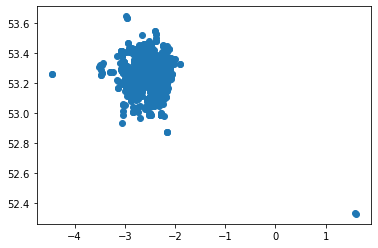

In [7]:
#Latitude and Longitude

#Get rows where either latitiude or longitude are null 
cheshire_search_df2.loc[cheshire_search_df2['Latitude'].isnull() | cheshire_search_df2['Longitude'].isnull()]

#Make new columns with null values replaced with the mean
cheshire_search_df2['nLatitude'] = cheshire_search_df2['Latitude'].fillna(cheshire_search_df2['Latitude'].mean())
cheshire_search_df2['nLongitude'] = cheshire_search_df2['Longitude'].fillna(cheshire_search_df2['Longitude'].mean())

#Check range of latitude and logitude after replacing null values using a scatterplot
plt.scatter(x=cheshire_search_df2['nLongitude'], y=cheshire_search_df2['nLatitude'])
plt.show()

In [8]:
#Scatterplot shows some outliers 
#Use 3 times standard deviation away from the mean as range limits to find and remove outlier values 

#Find upper and lower qaurtile values for longitude 
longitude_lq = cheshire_search_df2['nLongitude'].mean() - 3 * cheshire_search_df2['nLongitude'].std()
longitude_uq = cheshire_search_df2['nLongitude'].mean() + 3 * cheshire_search_df2['nLongitude'].std()
                                                
#Find upper and lower qaurtile values for latitude
latitude_lq = cheshire_search_df2['nLatitude'].mean() - 3 * cheshire_search_df2['nLatitude'].std()
latitude_uq = cheshire_search_df2['nLatitude'].mean() + 3 * cheshire_search_df2['nLatitude'].std()


#Replace longitude outliers with upper and lower quartile values 
cheshire_search_df2.loc[cheshire_search_df2['nLongitude'] > longitude_uq, 'nLongitude'] = longitude_uq
cheshire_search_df2.loc[cheshire_search_df2['nLongitude'] < longitude_lq, 'nLongitude'] = longitude_lq

#Replace latitude outliers with upper and lower quartile values 
cheshire_search_df2.loc[cheshire_search_df2['nLatitude'] > latitude_uq, 'nLatitude'] = latitude_uq
cheshire_search_df2.loc[cheshire_search_df2['nLatitude'] < latitude_lq, 'nLatitude'] = latitude_lq

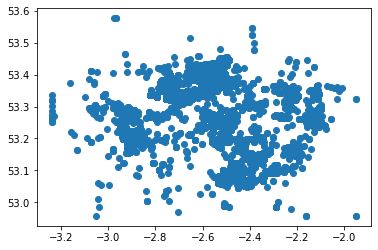

In [9]:
#Plot another scatterplot to check all outliers have been changed
plt.scatter(x=cheshire_search_df2['nLongitude'], y=cheshire_search_df2['nLatitude'])
plt.show()

In [10]:
#Gender 

#Use value_counts to find null values and column values 
cheshire_search_df2['Gender'].value_counts(dropna = False) 
#532 null values 

#Make a new column to replace nulls with 'Not stated'
cheshire_search_df2['nGender'] = cheshire_search_df2['Gender'].fillna('Not Stated')

#Show value_counts again to check all null values have been removed
cheshire_search_df2['nGender'].value_counts(dropna = False) 

Male          21894
Female         3506
Not Stated      532
Other            29
Name: nGender, dtype: int64

In [11]:
#Age range 

#Use value_counts to find null values and column values 
cheshire_search_df2['Age range'].value_counts(dropna = False) 
#17808 nan values 

#Make a new column to replace nulls with 'Not stated'
cheshire_search_df2['nAge range'] = cheshire_search_df2['Age range'].fillna('Not Stated')

#Show value_counts again to check all null values have been removed
cheshire_search_df2['nAge range'].value_counts(dropna = False) 

Not Stated    17808
over 34        2478
18-24          1986
10-17          1854
25-34          1835
Name: nAge range, dtype: int64

In [12]:
#Self-defined ethnicity

#Use value_counts to find null values and column values
cheshire_search_df2['Self-defined ethnicity'].value_counts(dropna = False)
#724 null values 

#Create a new column to replace nulls with 'Other ethnic group - Not stated' and check value_counts
cheshire_search_df2['nSelf-defined ethnicity'] = cheshire_search_df2['Self-defined ethnicity'].fillna('Other ethnic group - Not stated') 
cheshire_search_df2['nSelf-defined ethnicity'].value_counts(dropna = False)

White - English/Welsh/Scottish/Northern Irish/British                                   19945
Other ethnic group - Not stated                                                          2149
White - Any other White background                                                        988
Other ethnic group - Any other ethnic group                                               406
Black/African/Caribbean/Black British - Any other Black/African/Caribbean background      338
White - Irish                                                                             299
Asian/Asian British - Pakistani                                                           251
Asian/Asian British - Any other Asian background                                          242
Black/African/Caribbean/Black British - African                                           238
Mixed/Multiple ethnic groups - Any other Mixed/Multiple ethnic background                 237
Mixed/Multiple ethnic groups - White and Black Caribbean    

In [13]:
#Officer-defined ethnicity

#Use value_counts to find null values and column values
cheshire_search_df2['Officer-defined ethnicity'].value_counts(dropna = False)
#722 nulls 

#Create a new column to replace nulls with 'Not stated' and check value_counts
cheshire_search_df2['nOfficer-defined ethnicity'] = cheshire_search_df2['Officer-defined ethnicity'].fillna('Not stated') 
cheshire_search_df2['nOfficer-defined ethnicity'].value_counts(dropna = False)


White         22939
Black           907
Asian           811
Not stated      722
Other           582
Name: nOfficer-defined ethnicity, dtype: int64

In [14]:
#Legislation 

#Use value_counts to find null values and column values
cheshire_search_df2['Legislation'].value_counts(dropna = False)
#218 null values 

#Create a new column to replace nulls with 'Not stated' and check value_counts
cheshire_search_df2['nLegislation'] = cheshire_search_df2['Legislation'].fillna('Not stated') 
cheshire_search_df2['nLegislation'].value_counts(dropna = False)

Misuse of Drugs Act 1971 (section 23)                      17923
Police and Criminal Evidence Act 1984 (section 1)           7492
Not stated                                                   218
Criminal Justice and Public Order Act 1994 (section 60)      181
Firearms Act 1968 (section 47)                               124
Poaching Prevention Act 1862 (section 2)                       8
Psychoactive Substances Act 2016 (s36(2))                      7
Criminal Justice Act 1988 (section 139B)                       2
Crossbows Act 1987 (section 4)                                 2
Aviation Security Act 1982 (section 27(1))                     2
Wildlife and Countryside Act 1981 (section 19)                 2
Name: nLegislation, dtype: int64

In [15]:
#Object of search 

#Use value_counts to find null values and column values
cheshire_search_df2['Object of search'].value_counts(dropna = False)
#220 null values

#Create a new column to replace nulls with 'Not stated' and check value_counts
cheshire_search_df2['nObject of search'] = cheshire_search_df2['Object of search'].fillna('Not stated') 
cheshire_search_df2['nObject of search'].value_counts(dropna = False)

Controlled drugs                       17923
Offensive weapons                       2862
Article for use in theft                2264
Stolen goods                            1492
Articles for use in criminal damage      982
Not stated                               220
Firearms                                 124
Fireworks                                 75
Game or poaching equipment                 8
Psychoactive substances                    7
Crossbows                                  2
Evidence of wildlife offences              2
Name: nObject of search, dtype: int64

In [16]:
#Outcome and Outcome linked to object of search

#Outcome 

#Use value_counts to find null values and column values
cheshire_search_df2['Outcome'].value_counts(dropna = False)
#722 nulls 

#Outcome linked to object search 

#Use value_counts to find null values and column values
cheshire_search_df2['Outcome linked to object of search'].value_counts(dropna = False)
#722 nulls 

#Both have the same number of nulls which makes sense as there is no outcome for both (columns are connected)
#Create new columns replacing nulls with 'No Outcome' and check value_counts

#Outcome 
cheshire_search_df2['nOutcome'] = cheshire_search_df2['Outcome'].fillna('No Outcome')
cheshire_search_df2['nOutcome'].value_counts(dropna = False)

#Outcome linked to object search 
cheshire_search_df2['nOutcome linked to object of search'] = cheshire_search_df2['Outcome linked to object of search'].fillna('No Outcome')
cheshire_search_df2['nOutcome linked to object of search'].value_counts(dropna = False)

False         17842
True           7397
No Outcome      722
Name: nOutcome linked to object of search, dtype: int64

In [17]:
#Removal of more than just outer clothing

#Use value_counts to find null values and column values
cheshire_search_df2['Removal of more than just outer clothing'].value_counts(dropna = False) 
#722 nulls


#Create a new column replacing null values with 'Not stated' and check value_counts 
cheshire_search_df2['nRemoval of more than just outer clothing'] = cheshire_search_df2['Removal of more than just outer clothing'].fillna('Not stated')
cheshire_search_df2['nRemoval of more than just outer clothing'].value_counts(dropna = False) 

False         24921
Not stated      722
True            318
Name: nRemoval of more than just outer clothing, dtype: int64

In [18]:
#Use the info function to understand what the final cleaned dataset looks like 
cheshire_search_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25961 entries, 0 to 25960
Data columns (total 24 columns):
 #   Column                                     Non-Null Count  Dtype              
---  ------                                     --------------  -----              
 0   Type                                       25961 non-null  object             
 1   Date                                       25961 non-null  datetime64[ns, UTC]
 2   Latitude                                   23988 non-null  float64            
 3   Longitude                                  23988 non-null  float64            
 4   Gender                                     25429 non-null  object             
 5   Age range                                  8153 non-null   object             
 6   Self-defined ethnicity                     25237 non-null  object             
 7   Officer-defined ethnicity                  25239 non-null  object             
 8   Legislation                                257

We can now complete the same process for the Cheshire street dataset 


In [19]:
#Use the info function to understand what columns are included and the size and shape of the data
cheshire_street_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172853 entries, 0 to 172852
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               156778 non-null  object 
 1   Month                  172853 non-null  object 
 2   Reported by            172853 non-null  object 
 3   Falls within           172853 non-null  object 
 4   Longitude              172849 non-null  float64
 5   Latitude               172849 non-null  float64
 6   Location               172853 non-null  object 
 7   LSOA code              172849 non-null  object 
 8   LSOA name              172849 non-null  object 
 9   Crime type             172853 non-null  object 
 10  Last outcome category  156778 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 15.8+ MB


In [20]:
#Create a new dataset without context column as all values are null 
cheshire_street_df2 = cheshire_street_df.drop(columns = ['Context'],axis =1)

#Use info funcion to look at new dataset
cheshire_street_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172853 entries, 0 to 172852
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               156778 non-null  object 
 1   Month                  172853 non-null  object 
 2   Reported by            172853 non-null  object 
 3   Falls within           172853 non-null  object 
 4   Longitude              172849 non-null  float64
 5   Latitude               172849 non-null  float64
 6   Location               172853 non-null  object 
 7   LSOA code              172849 non-null  object 
 8   LSOA name              172849 non-null  object 
 9   Crime type             172853 non-null  object 
 10  Last outcome category  156778 non-null  object 
dtypes: float64(2), object(9)
memory usage: 14.5+ MB


In [21]:
#Crime ID 

#Check for null values 
cheshire_street_df2.loc[cheshire_street_df2['Crime ID'].isnull()]

#Since Crime Id is a unique identifier make a new dataset without the instances with a null crime id 
cheshire_street_df3 = cheshire_street_df2.loc[cheshire_street_df2['Crime ID'].notnull()].copy()

In [22]:
#Use the info function to check the new dataset has been made correctly 
cheshire_street_df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156778 entries, 0 to 172852
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               156778 non-null  object 
 1   Month                  156778 non-null  object 
 2   Reported by            156778 non-null  object 
 3   Falls within           156778 non-null  object 
 4   Longitude              156774 non-null  float64
 5   Latitude               156774 non-null  float64
 6   Location               156778 non-null  object 
 7   LSOA code              156774 non-null  object 
 8   LSOA name              156774 non-null  object 
 9   Crime type             156778 non-null  object 
 10  Last outcome category  156778 non-null  object 
dtypes: float64(2), object(9)
memory usage: 14.4+ MB


In [23]:
#Month 

#Change column type to Datetime and use the to period function to only show the month and year
cheshire_street_df3['Month'] = pd.to_datetime(cheshire_street_df3['Month']).dt.to_period('M')

#Check range of dates for any outliers by finding the min and max
print(str(cheshire_street_df3['Month'].min())+ ' to ' + str(cheshire_street_df3['Month'].max()))

2024-01 to 2026-01


In [24]:
#Reported by and Falls within

#Use value_counts to find null values and column values

#Reported by
cheshire_street_df3['Reported by'].value_counts(dropna = False)
#No nulls all constant values

#Falls within
cheshire_street_df3['Falls within'].value_counts(dropna = False)
#No nulls all constant values that match reported by column

Cheshire Constabulary    156778
Name: Falls within, dtype: int64

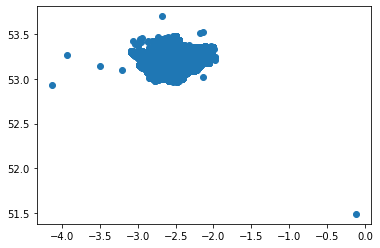

In [25]:
#Latitude and Longitude

#Get rows where either latitiude or longitude are null 
cheshire_street_df3.loc[cheshire_street_df3['Latitude'].isnull() | cheshire_street_df3['Longitude'].isnull()]

#Make new columns with null values replaced with the mean
cheshire_street_df3['nLatitude'] = cheshire_street_df3['Latitude'].fillna(cheshire_street_df3['Latitude'].mean())
cheshire_street_df3['nLongitude'] = cheshire_street_df3['Longitude'].fillna(cheshire_street_df3['Longitude'].mean())

#Check range of latitude and logitude after replacing null values using a scatterplot
plt.scatter(x=cheshire_street_df3['nLongitude'], y=cheshire_street_df3['nLatitude'])
plt.show()

In [26]:
#Scatterplot shows some signifcant outliers 
#Use 3 times standard deviation away from the mean as range limits to find and remove outlier values 

#Find upper and lower qaurtile values for longitude 
longitude_lq = cheshire_street_df3['nLongitude'].mean() - 3 * cheshire_street_df3['nLongitude'].std()
longitude_uq = cheshire_street_df3['nLongitude'].mean() + 3 * cheshire_street_df3['nLongitude'].std()
                                                
#Find upper and lower qaurtile values for latitude
latitude_lq = cheshire_street_df3['nLatitude'].mean() - 3 * cheshire_street_df3['nLatitude'].std()
latitude_uq = cheshire_street_df3['nLatitude'].mean() + 3 * cheshire_street_df3['nLatitude'].std()


#Replace longitude outliers with upper and lower quartile values 
cheshire_street_df3.loc[cheshire_street_df3['nLongitude'] > longitude_uq, 'nLongitude'] = longitude_uq
cheshire_street_df3.loc[cheshire_street_df3['nLongitude'] < longitude_lq, 'nLongitude'] = longitude_lq

#Replace latitude outliers with upper and lower quartile values 
cheshire_street_df3.loc[cheshire_street_df3['nLatitude'] > latitude_uq, 'nLatitude'] = latitude_uq
cheshire_street_df3.loc[cheshire_street_df3['nLatitude'] < latitude_lq, 'nLatitude'] = latitude_lq

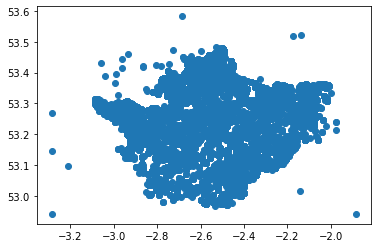

In [27]:
#Produce another scatterplot to check values have been changed correctly and there are no more outliers 
plt.scatter(x=cheshire_street_df3['nLongitude'], y=cheshire_street_df3['nLatitude'])
plt.show()

In [28]:
#Location

#Use nunique function to find the number of unique values in the column
cheshire_street_df3['Location'].nunique()
#10547 unique values 

#Check to see if any values are null 
cheshire_street_df3.loc[cheshire_street_df3['Location'].isnull()]
#No null values 

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,nLatitude,nLongitude


In [29]:
#LSOA code

#Use nunique function to find the number of unique values in the column
cheshire_street_df3['LSOA code'].nunique()
#739 unique values

#Check to see if any values are null 
cheshire_street_df3.loc[cheshire_street_df3['LSOA code'].isnull()]
#4 null values and all instances have no values for LSOA name and Location variables

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,nLatitude,nLongitude
14983,1bdeb88a4650d69633c7970cf3a66e8723f875ea578141...,2024-07,Cheshire Constabulary,Cheshire Constabulary,NaN,NaN,No Location,NaN,NaN,Possession of weapons,Court result unavailable,53.262389,-2.584554
14984,5617a57982bc9c5baca2e19bf9165ffc6066d8422e60f4...,2024-07,Cheshire Constabulary,Cheshire Constabulary,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,53.262389,-2.584554
22421,f9721db253be2a26b46c2c04274a22151f42c0352914f2...,2024-06,Cheshire Constabulary,Cheshire Constabulary,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,53.262389,-2.584554
22422,0fa33e37eb62f648d547f4cdf3176535b319fb2338125f...,2024-06,Cheshire Constabulary,Cheshire Constabulary,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Status update unavailable,53.262389,-2.584554


In [30]:
#Since the amount of null values is so small create a new dataset without the null instances 
cheshire_street_df4 = cheshire_street_df3.loc[cheshire_street_df3['LSOA code'].notnull()].copy()

#Use the info function to check the new datset has been created correctly
cheshire_street_df4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156774 entries, 0 to 172852
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype    
---  ------                 --------------   -----    
 0   Crime ID               156774 non-null  object   
 1   Month                  156774 non-null  period[M]
 2   Reported by            156774 non-null  object   
 3   Falls within           156774 non-null  object   
 4   Longitude              156774 non-null  float64  
 5   Latitude               156774 non-null  float64  
 6   Location               156774 non-null  object   
 7   LSOA code              156774 non-null  object   
 8   LSOA name              156774 non-null  object   
 9   Crime type             156774 non-null  object   
 10  Last outcome category  156774 non-null  object   
 11  nLatitude              156774 non-null  float64  
 12  nLongitude             156774 non-null  float64  
dtypes: float64(4), object(8), period[M](1)
memory usage: 16.7+ 

In [31]:
#LSOA name

#Use nunique function to find the number of unique values in the column
cheshire_street_df4['LSOA name'].nunique()
#739 unique values 
#This is the same value as LSOA code which is correct as these two columns are connected

#Check for null values 
cheshire_street_df4.loc[cheshire_street_df4['LSOA name'].isnull()]

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,nLatitude,nLongitude


In [32]:
#Crime type

#Use value_counts to find any null values and understand what values are in the column
cheshire_street_df4['Crime type'].value_counts(dropna = False)
#No null values and all column values make sense  


Violence and sexual offences    78922
Public order                    18128
Criminal damage and arson       11668
Shoplifting                     11600
Other theft                     10391
Drugs                            7043
Burglary                         5430
Other crime                      4605
Vehicle crime                    4511
Possession of weapons            1571
Bicycle theft                    1413
Robbery                           906
Theft from the person             586
Name: Crime type, dtype: int64

In [33]:
#Last outocme category

#Use value_counts to find any null values and understand what values are in the column
cheshire_street_df4['Last outcome category'].value_counts(dropna = False)
#No null values and all column values make sense  

Unable to prosecute suspect                            66579
Investigation complete; no suspect identified          40790
Court result unavailable                               10933
Status update unavailable                               9682
Local resolution                                        8633
Awaiting court outcome                                  6672
Under investigation                                     5816
Action to be taken by another organisation              3650
Further investigation is not in the public interest     1817
Offender given a caution                                 980
Formal action is not in the public interest              661
Further action is not in the public interest             525
Suspect charged as part of another case                   36
Name: Last outcome category, dtype: int64

In [34]:
#Use the info function to view final clean dataset 
cheshire_street_df4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156774 entries, 0 to 172852
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype    
---  ------                 --------------   -----    
 0   Crime ID               156774 non-null  object   
 1   Month                  156774 non-null  period[M]
 2   Reported by            156774 non-null  object   
 3   Falls within           156774 non-null  object   
 4   Longitude              156774 non-null  float64  
 5   Latitude               156774 non-null  float64  
 6   Location               156774 non-null  object   
 7   LSOA code              156774 non-null  object   
 8   LSOA name              156774 non-null  object   
 9   Crime type             156774 non-null  object   
 10  Last outcome category  156774 non-null  object   
 11  nLatitude              156774 non-null  float64  
 12  nLongitude             156774 non-null  float64  
dtypes: float64(4), object(8), period[M](1)
memory usage: 16.7+ 

Using the methods used to clean the cheshire datasets, functions can now be made and then applied to the remaining regions

Start by defining the functions

In [35]:
#A function that changes the data type of the month/date columns to the correct form 
def change_date_type(df: pd.DataFrame):
    try:
        #For the date column in the stop and search data
        if df.columns.isin(['Date']).any():
            df['Date'] = pd.to_datetime(df['Date'])
        #For the month column in the street data 
        elif df.columns.isin(['Month']).any():
            #Use the to_period to only get the month and year 
            df['Month'] = pd.to_datetime(df['Month']).dt.to_period('M')
    except ValueError:
            #If any error occurs do not change any values 
            pass
    return df 

In [36]:
#A function that cleans the longitude and latitiude columns 
#Can only be applied to the seperated datasets so that regions are not mixed together
def long_and_lat(df: pd.DataFrame):
    try:
        #Replace null values replaced with the mean of that region
        df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mean())
        df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mean())

        #Find upper and lower qaurtile values for longitude 
        longitude_lq = df['Longitude'].mean() - 3 * df['Longitude'].std()
        longitude_uq = df['Longitude'].mean() + 3 * df['Longitude'].std()

        #Find upper and lower qaurtile values for latitude
        latitude_lq = df['Latitude'].mean() - 3 * df['Latitude'].std()
        latitude_uq = df['Latitude'].mean() + 3 * df['Latitude'].std()

        #Replace longitude outliers with upper and lower quartile values 
        df.loc[df['Longitude'] > longitude_uq, 'Longitude'] = longitude_uq
        df.loc[df['Longitude'] < longitude_lq, 'Longitude'] = longitude_lq

        #Replace latitude outliers with upper and lower quartile values 
        df.loc[df['Latitude'] > latitude_uq, 'Latitude'] = latitude_uq
        df.loc[df['Latitude'] < latitude_lq, 'Latitude'] = latitude_lq
        
    except ValueError:
            #If an error occurs then do not change any value
            pass
    return df 

In [37]:
#A function that replaces the null values in the catagorical data columns in the stop and search datasets 
#with the appropriate value
def not_stated(df: pd.DataFrame):
    try:
        df['Gender'] = df['Gender'].fillna('Not stated')
        df['Age range'] = df['Age range'].fillna('Not stated')
        
        #Self-defined ethnicity already has a category for undefined values which we can assign the nulls to 
        df['Self-defined ethnicity'] = df['Self-defined ethnicity'].fillna('Other ethnic group - Not stated')
        
        df['Officer-defined ethnicity'] = df['Officer-defined ethnicity'].fillna('Not stated')        
        df['Legislation'] = df['Legislation'].fillna('Not stated')
        df['Object of search'] = df['Object of search'].fillna('Not stated')
        df['Outcome'] = df['Outcome'].fillna('Not stated')
        df['Outcome linked to object of search'] = df['Outcome linked to object of search'].fillna('Not stated')
        df['Removal of more than just outer clothing'] = df['Removal of more than just outer clothing'].fillna('Not stated')       
    except ValueError:
            #If an error occurs do not assign a new value
            pass
    return df 

In [38]:
#A function that drops any row in the street datasets that has a null crime ID
def drop_crimeID(df: pd.DataFrame):
    try:
        df = df.loc[df['Crime ID'].notnull()]
    except ValueError:
            #If an error occurs do not delete any rows
            pass
    return df         

In [39]:
#A function that drops a row in the street datasets that do not have a location
def drop_LSOA(df: pd.DataFrame):
    try:       
        df = df.loc[df['LSOA code'].notnull() | df['LSOA name'].notnull()]        
    except ValueError:
            pass
    return df            

Apply functions to the seperate datasets before combining the different regions

In [40]:
#Add police force column to identify where the stop and search took place
cheshire_search_df['Police Force'] = "Cheshire Police"
kent_search_df['Police Force'] = "Kent Police"
lincolnshire_search_df['Police Force'] = "Lincolnshire Police"
sussex_search_df['Police Force'] = "Sussex Police"

In [41]:
#Create lists of the datasets seperated by whether they are stop and search or street
search = [cheshire_search_df,kent_search_df,lincolnshire_search_df,sussex_search_df]
street = [cheshire_street_df,kent_street_df,lincolnshire_street_df,sussex_street_df]

In [43]:
#Use the long_and_lat function to clean all longitude and latitude columns 

#Since all datasets have a longitude and latitude column both lists can be comnined
all_datasets = search + street

#Loop through all the datasets and apply the long_and_lat function
for i in all_datasets: 
    i = long_and_lat(i)

Now all the datasets can be combined as the remaining functions do not need to be applied to a specific region

In [44]:
#Merge all datsets together 

#Stop and search data 
stop_and_search_df = pd.concat(search)

#Street crimes 
street_df = pd.concat(street)

In [45]:
#Use the info to find the size and shape of the combined stop and search data 
stop_and_search_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 77715 entries, 0 to 12625
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Type                                      77715 non-null  object 
 1   Date                                      77715 non-null  object 
 2   Part of a policing operation              46527 non-null  float64
 3   Policing operation                        0 non-null      float64
 4   Latitude                                  77715 non-null  float64
 5   Longitude                                 77715 non-null  float64
 6   Gender                                    63102 non-null  object 
 7   Age range                                 54738 non-null  object 
 8   Self-defined ethnicity                    72909 non-null  object 
 9   Officer-defined ethnicity                 74692 non-null  object 
 10  Legislation                       

In [46]:
#Apply the remaining functions to the stop ad search dataset 

#Change the data type of the Date column to the correct form
stop_and_search_df = change_date_type(stop_and_search_df).copy()

#Replace all null values for the catagorical data with the appropirate value 
stop_and_search_df = not_stated(stop_and_search_df).copy()

#Drop the Policing operation and Part of a policing operation columns due to majority of values being null 
stop_and_search_df = stop_and_search_df.drop(columns=['Policing operation','Part of a policing operation'], axis=1)

In [47]:
#Use the info function to check full dataset has been fully cleaned 
stop_and_search_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 77715 entries, 0 to 12625
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype              
---  ------                                    --------------  -----              
 0   Type                                      77715 non-null  object             
 1   Date                                      77715 non-null  datetime64[ns, UTC]
 2   Latitude                                  77715 non-null  float64            
 3   Longitude                                 77715 non-null  float64            
 4   Gender                                    77715 non-null  object             
 5   Age range                                 77715 non-null  object             
 6   Self-defined ethnicity                    77715 non-null  object             
 7   Officer-defined ethnicity                 77715 non-null  object             
 8   Legislation                               77715 non-null

In [48]:
#Use the info function to find the current state of the combined street crime dataset
street_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016378 entries, 0 to 321912
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Crime ID               857196 non-null   object 
 1   Month                  1016378 non-null  object 
 2   Reported by            1016378 non-null  object 
 3   Falls within           1016378 non-null  object 
 4   Longitude              1016378 non-null  float64
 5   Latitude               1016378 non-null  float64
 6   Location               1016378 non-null  object 
 7   LSOA code              999678 non-null   object 
 8   LSOA name              999678 non-null   object 
 9   Crime type             1016378 non-null  object 
 10  Last outcome category  857196 non-null   object 
 11  Context                0 non-null        float64
dtypes: float64(3), object(9)
memory usage: 100.8+ MB


In [49]:
#Apply the remaining functions to the street crimes dataset 

#Change the month column to the correct datatype 
street_df = change_date_type(street_df).copy()

#Drop all rows that have a null crime Id value
street_df = drop_crimeID(street_df).copy()

#Drop all rows that have no location stated 
street_df = drop_LSOA(street_df).copy()

#Drop the context column due to all values being null 
street_df = street_df.drop(columns=['Context'],axis =1)

In [50]:
#Use the info function to check the final datset is fully clean
street_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 840644 entries, 0 to 321251
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype    
---  ------                 --------------   -----    
 0   Crime ID               840644 non-null  object   
 1   Month                  840644 non-null  period[M]
 2   Reported by            840644 non-null  object   
 3   Falls within           840644 non-null  object   
 4   Longitude              840644 non-null  float64  
 5   Latitude               840644 non-null  float64  
 6   Location               840644 non-null  object   
 7   LSOA code              840644 non-null  object   
 8   LSOA name              840644 non-null  object   
 9   Crime type             840644 non-null  object   
 10  Last outcome category  840644 non-null  object   
dtypes: float64(2), object(8), period[M](1)
memory usage: 77.0+ MB


New CSV files need to be created to allow for the fully cleaned datasets to be imported to perform exploratory data analysis on

In [54]:
#Save the cleaned stop and search dataset as a csv in a folder called cleaned 
stop_and_search_df.to_csv("Data/Cleaned/stop_search.csv")

#Save the cleaned street crimes dataset as a csv in a folder called cleaned 
street_df.to_csv("Data/Cleaned/street.csv")